# Chapter 1: Databases and Database Users


## Teaching Summary

Why do several offices need an agreed source of student information? This chapter
introduces databases, the software that manages them, and the limits of that software.
Read this after the course syllabus. No programming knowledge is required.

Textbook: Elmasri and Navathe, *Fundamentals of Database Systems*, seventh edition.
This introductory selection uses Sections 1.1-1.3 and selected benefits from 1.6.
The examples and diagrams are original, synthetic teaching examples, not university
records or copied textbook figures.

By the end, you should be able to distinguish data from a DBMS, identify a conflicting
fact, read a simple catalog description, and explain why users can need different views.
You should also be able to name something a DBMS cannot establish from stored data alone.


## 1. Data, Software, and a Database System

A **database** is a collection of related data with an intended meaning and purpose.
For example, student information and course registrations can support the question
"Which students should receive this course announcement?" A collection of unrelated
numbers without a defined meaning would not answer that question.

A **database management system (DBMS)** is software for defining, constructing,
retrieving, changing, and sharing databases. The database and its DBMS together form
a **database system**. The displayed table is data, not the DBMS software.

In this course, Python sends commands to SQLite. SQLite is the DBMS; the stored
student rows are part of the database. A database need not be hosted on a network
server. Our examples can use SQLite inside the same process as Python.

**Predict before reading the diagram:** Which part contains a student's email?
Which part processes a request to retrieve it?


### A request, the DBMS, and stored data

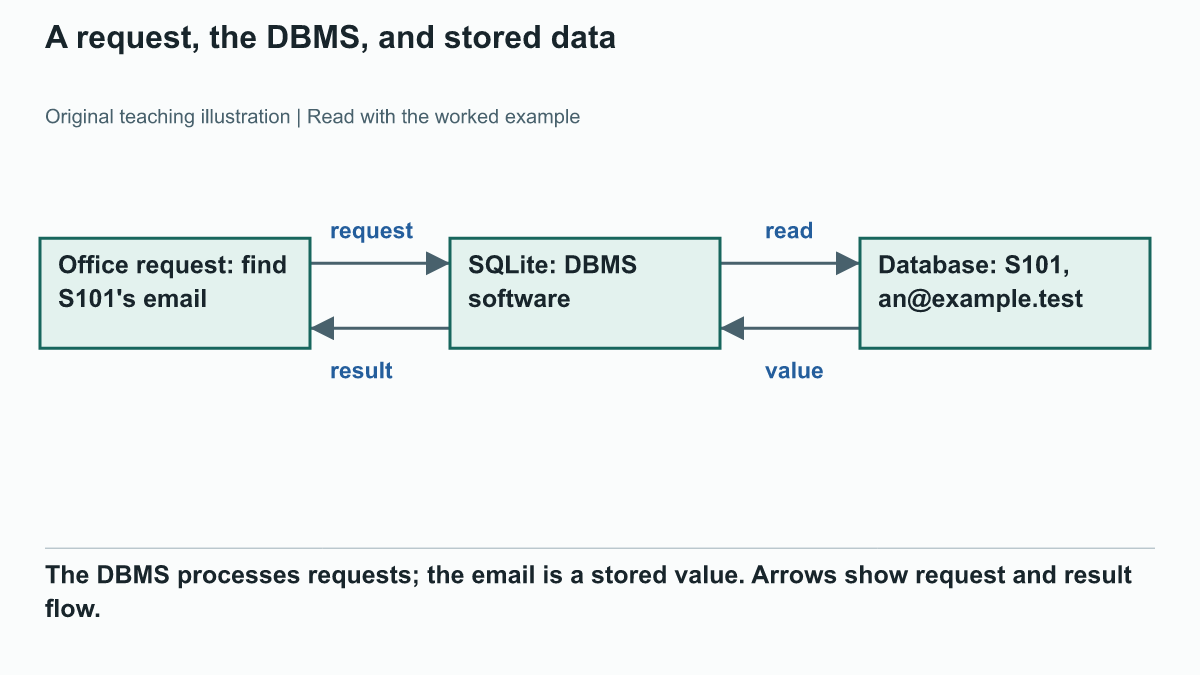

The DBMS processes requests; the email is a stored value. Arrows show request and result flow.


### Read the Diagram

The email belongs to the stored data. SQLite processes the request. The arrows show
a request moving toward the data and a result returning to the user; they do not
mean that the user directly edits a picture of a table.

**Practice:** Identify the data, request, and DBMS when an office asks for S101's
email. Then explain why a screenshot of the answer is not itself the DBMS.
Check that your three descriptions name different things.


## 2. Two Files Can Disagree

Suppose two offices maintain their own copies of the same student's contact details.
Repeated storage of the same fact creates work: a correction may have to reach both
copies. An **inconsistency** occurs here when the same student has different recorded
emails although the case permits only one current contact email.

| Office file | student_id | email |
|---|---|---|
| Registration | S101 | an@example.test |
| Course contact | S101 | an.old@example.test |

**Predict:** Can either row establish which address is current? Name the exact
attribute that disagrees before reading the explanation.


### The same ID has conflicting contact values

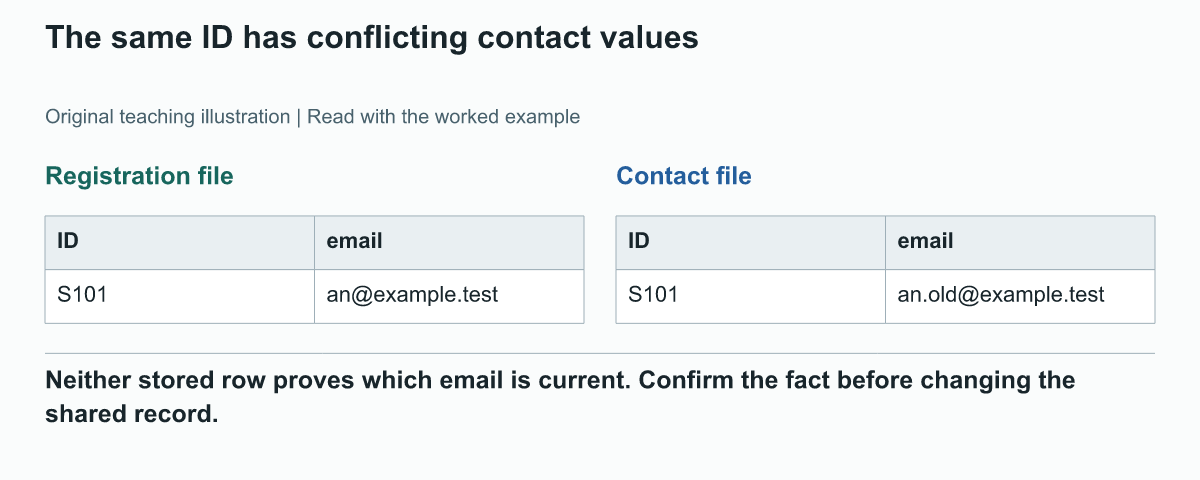

Neither stored row proves which email is current. Confirm the fact before changing the shared record.


### Read the Diagram

The emails disagree. Neither file contains evidence that settles which email is
current. For this example, assume the office checks S101's identity and obtains
confirmation that `an@example.test` is current. It can then record that confirmed
address in a shared database instead of leaving independent copies to drift apart.

The confirmation came from the stated verification, not from SQLite. A shared
database can reduce inconsistent copies, but it does not make an incorrect fact true.
Controlled redundancy may still be useful; using a DBMS does not eliminate every copy.

**Practice:** Suppose a third file also says `an.old@example.test`. Does a two-to-one
majority establish the current address? Record the evidence still needed before an
office sends a message. Check your answer against the distinction between repetition
of a value and verification of a fact.


## 3. The Catalog Describes the Data

A DBMS keeps descriptions of its database, often in a **catalog**. These descriptions
are **metadata**, meaning data about the structure or rules of other data.
An attribute name and its declared type describe a column; a student's actual name
is a value in that column. A DBMS uses the description when it processes commands.

Our simplified catalog says that `student_id` and `email` are text attributes of
`student`. This illustration shows only a few descriptions, not a complete catalog
or a guarantee that a declared text type verifies the truth of an email.

**Predict:** Is `email` metadata in this diagram? Is `an@example.test` metadata in
the same role? Point to the description and the stored value separately.


### A description is not the student's stored value

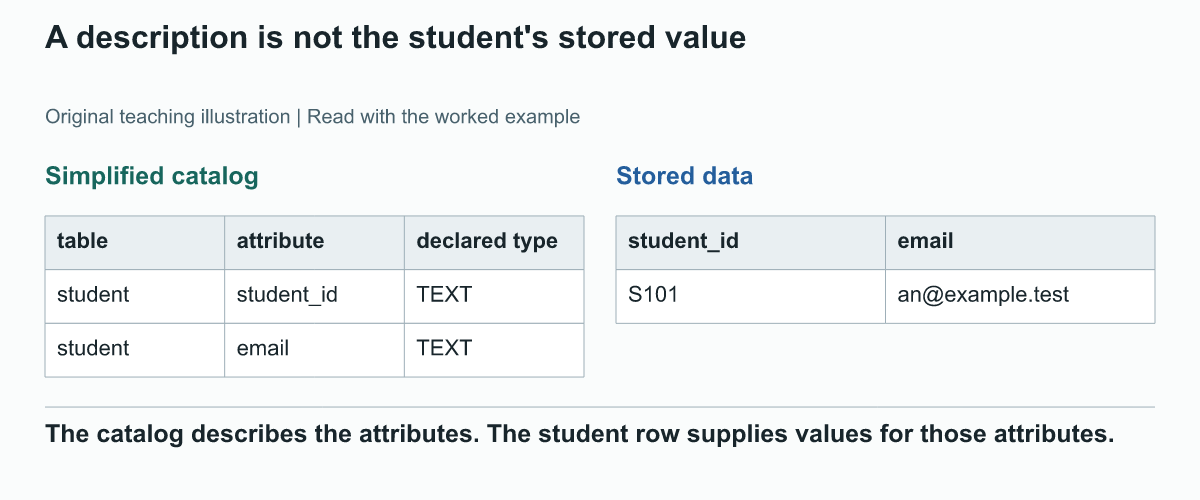

The catalog describes the attributes. The student row supplies values for those attributes.


### Read the Diagram

The name `email` describes an attribute. The string `an@example.test` is S101's
recorded value of that attribute. Replacing that value does not rename the attribute.
The distinction will help us separate a schema from a database state in Chapter 2.

**Practice:** For `course(course_id, title)`, write one example of metadata and one
example of stored course data. Your data must fit the attributes you named; a title
does not become a column name merely because it appears in a row.


## 4. Different Users Need Different Views

A **view** presents data relevant to a particular user or task. It may contain only
some stored attributes, or values derived from other data. A contact office needs
an email; a department summary needs department counts, not necessarily each email.

| student_id | email | dept_code |
|---|---|---|
| S101 | an@example.test | IM |
| S102 | bea@example.test | FIN |
| S103 | kai@example.test | IM |

**Predict:** Which attributes should the contact list show? How many students should
the department summary show for IM and FIN? These are two questions about the same
three rows, not two independently maintained sets of student facts.


### Two views of the same three student records

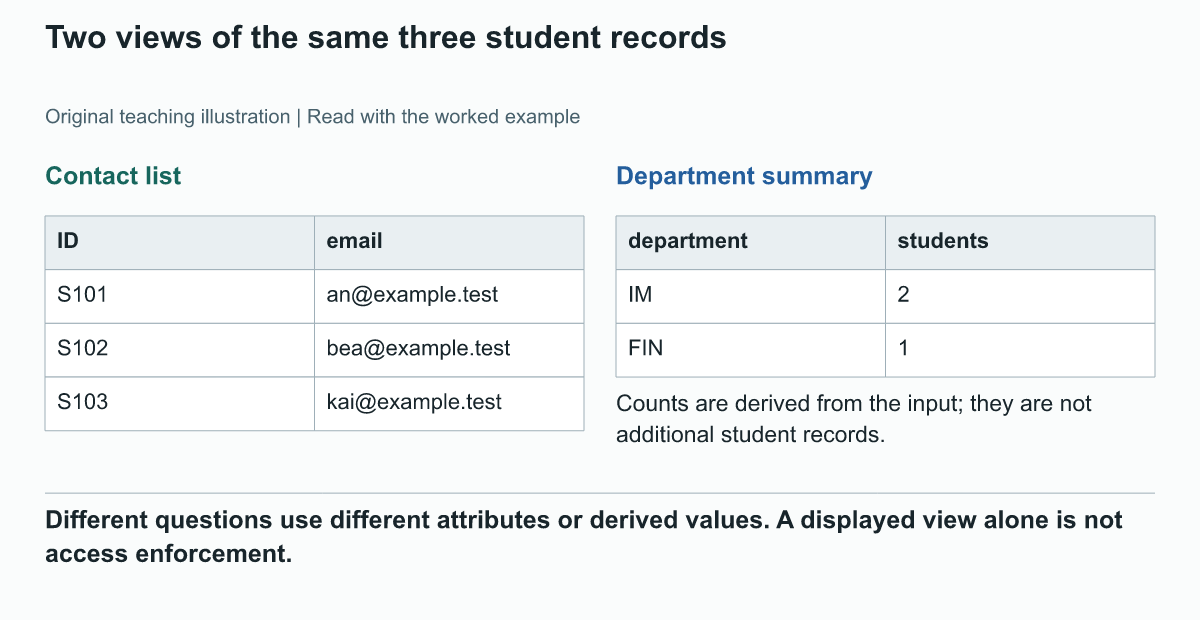

Different questions use different attributes or derived values. A displayed view alone is not access enforcement.


### Read the Diagram

The contact list shows three ID/email pairs. The summary shows IM with 2 students
and FIN with 1. A count is derived from the displayed rows; it was not a fourth
student stored in the input. A different view can answer a different question without
requiring a separate office to maintain another master copy of the facts.

These are conceptual views. Later SQL lessons implement views and queries. Hiding
an email in one diagram does not enforce access control; actual permissions must
restrict the ways a user can access the data.

**Practice:** Design a view for an office that needs student IDs and departments but
not email. List its columns and rows. Check that it exposes only the requested values.


## 5. Sharing Still Needs Rules

A shared database needs rules about who may read or change information and which
changes are allowed. For this example, a contact officer may update a verified email;
a summary reader may see department counts but may not change contact details.

A multiuser DBMS also needs to control simultaneous updates. If two requests both
try to reserve the last available place, simply sharing a table does not explain how
to prevent both from succeeding. Transaction concepts are taught later; no locking
algorithm is required here.

**Predict:** Should a summary reader's email-change request be accepted under the
stated policy? Does an email's valid text format prove it belongs to the student?


### Permission and factual correctness are separate checks

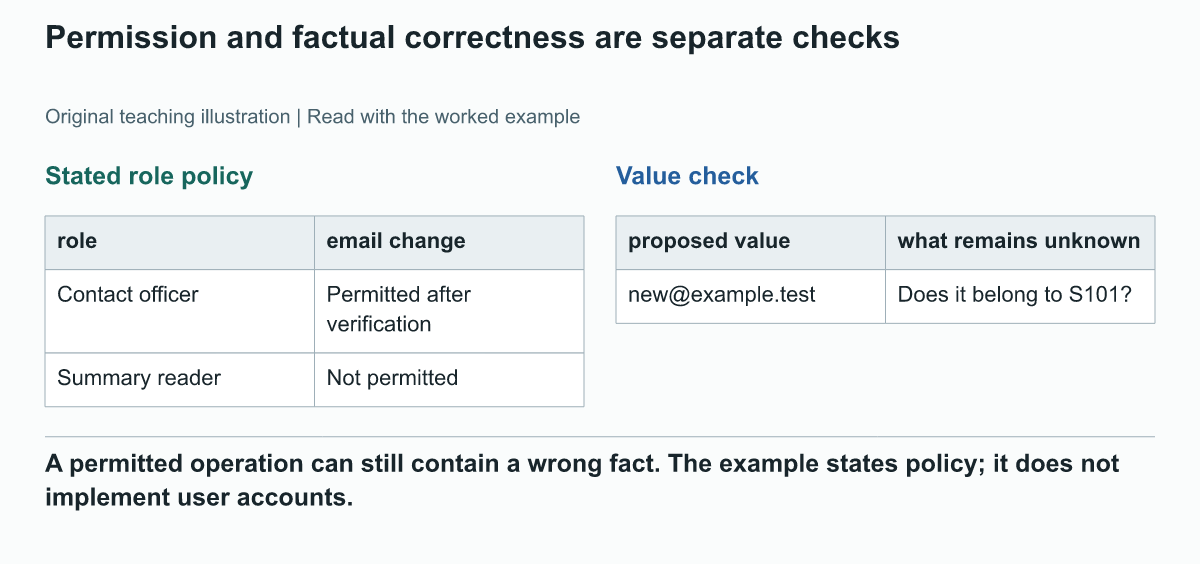

A permitted operation can still contain a wrong fact. The example states policy; it does not implement user accounts.


### Read the Diagram

The summary reader is not authorized to change the email. A contact officer's
permission does not establish the truth of the proposed value: identity and email
verification remain necessary. A DBMS can enforce specified restrictions; designers
must identify those restrictions, and not every business rule is automatically enforced.

**Practice:** Write one request that the policy allows and one it forbids. Then give
an allowed-looking value that could still be factually wrong. Judge each request
against the stated role and task, not against whether the SQL could run.


## Chapter Summary

- The database contains related facts; the DBMS manages access and changes.
- Shared data can reduce conflicting copies, but factual correctness still needs evidence.
- Catalog metadata describes data structure; it is not the same as a stored student value.
- Views can expose different subsets or derived results for different tasks.
- Sharing requires integrity and access rules, not just a common storage location.

Keep one prediction, your observed or worked-out result, and either a correction or
an explanation of why your prediction was correct. A correct prediction does not
require you to invent an error. Submit work only when the instructor assigns it.

Next, Chapter 2 separates models, schemas, and database states and explains basic
architecture. Finish here for this chapter's first-meeting selection; the remaining
Chapter 1 history, role taxonomy, and detailed DBMS features are not extra assigned work.
